In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
nav = pd.read_csv("../1.data/processed/nav_history_cleaned.csv")
transactions = pd.read_csv("../1.data/processed/transactions_cleaned.csv")
performance = pd.read_csv("../1.data/processed/scheme_performance_cleaned.csv")

print("NAV rows:", len(nav))
print("Transactions rows:", len(transactions))
print("Performance rows:", len(performance))

NAV rows: 46000
Transactions rows: 32778
Performance rows: 40


In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


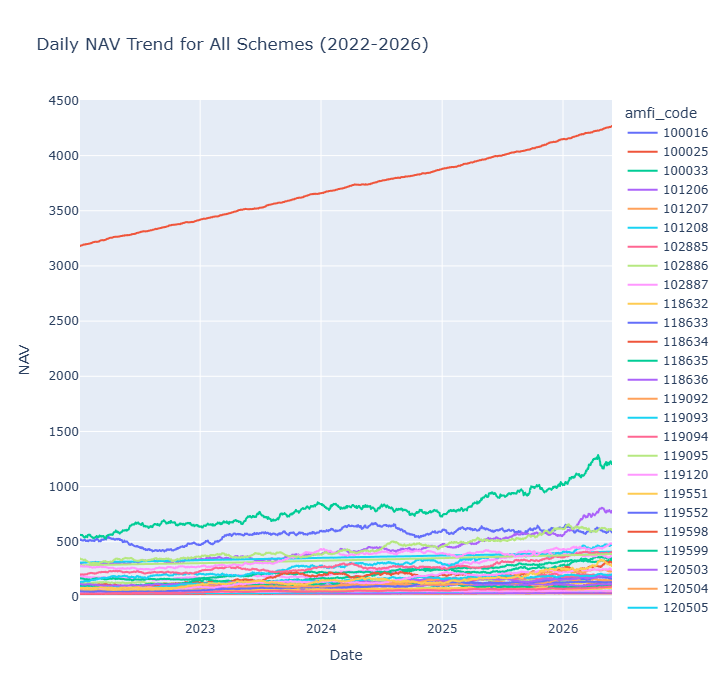

In [5]:
import plotly.express as px

# Convert date column to datetime
nav['date'] = pd.to_datetime(nav['date'])

fig = px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend for All Schemes (2022-2026)'
)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='NAV',
    height=700
)

fig.show()

### NAV Trend Analysis

The NAV values of mutual fund schemes show an overall upward trend between 2022 and 2026, indicating long-term growth despite periodic market fluctuations.

In [6]:
aum = pd.read_csv("../1.data/raw/03_aum_by_fund_house.csv")

print(aum.head())
print(aum.columns)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


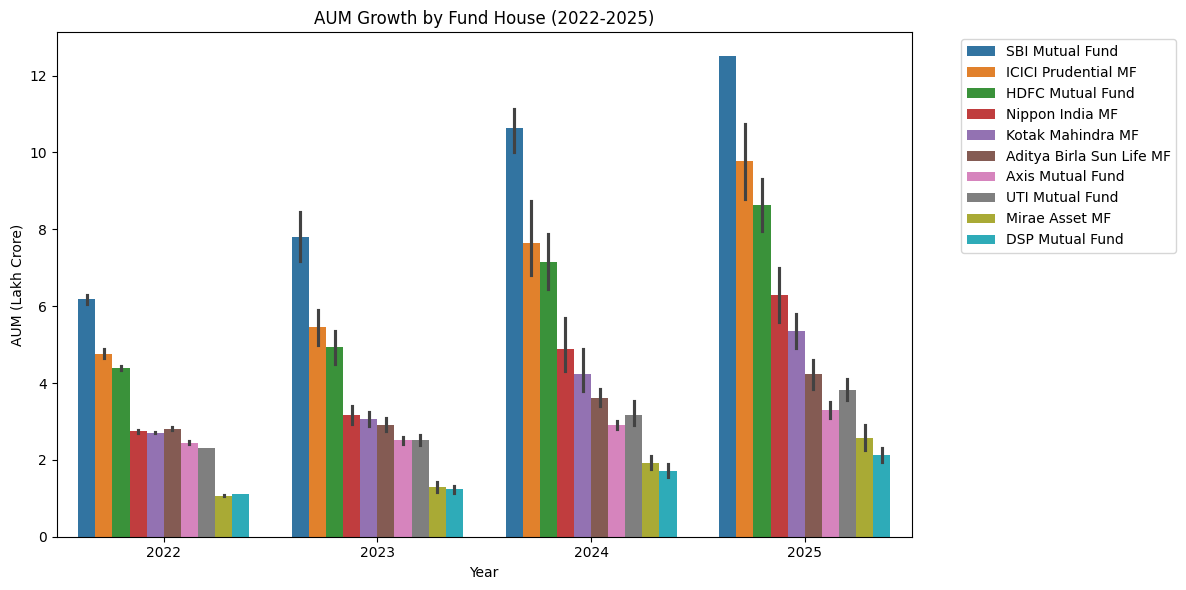

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
aum = pd.read_csv("../1.data/raw/03_aum_by_fund_house.csv")

# Convert date and extract year
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

# Create chart
plt.figure(figsize=(12,6))
sns.barplot(
    data=aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()

plt.show()

### AUM Growth Analysis

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among major fund houses, demonstrating strong market leadership throughout the period.

In [8]:
sip = pd.read_csv("../1.data/raw/04_monthly_sip_inflows.csv")

print(sip.head())
print(sip.columns)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


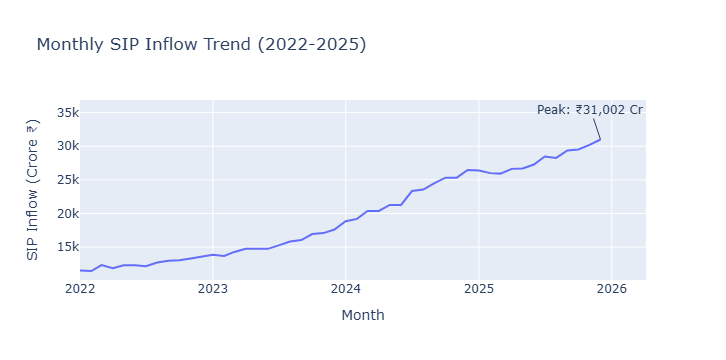

In [9]:
import plotly.express as px
import pandas as pd

# Convert month column
sip['month'] = pd.to_datetime(sip['month'])

# Create line chart
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (2022-2025)'
)

# Highlight highest SIP inflow
max_row = sip.loc[sip['sip_inflow_crore'].idxmax()]

fig.add_annotation(
    x=max_row['month'],
    y=max_row['sip_inflow_crore'],
    text=f"Peak: ₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP Inflow (Crore ₹)'
)

fig.show()

### SIP Inflow Analysis

Monthly SIP inflows showed strong and consistent growth from 2022 to 2025, reaching an all-time high in late 2025, indicating increasing retail investor participation in mutual funds.


In [10]:
category = pd.read_csv("../1.data/raw/05_category_inflows.csv")

print(category.head())
print(category.columns)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


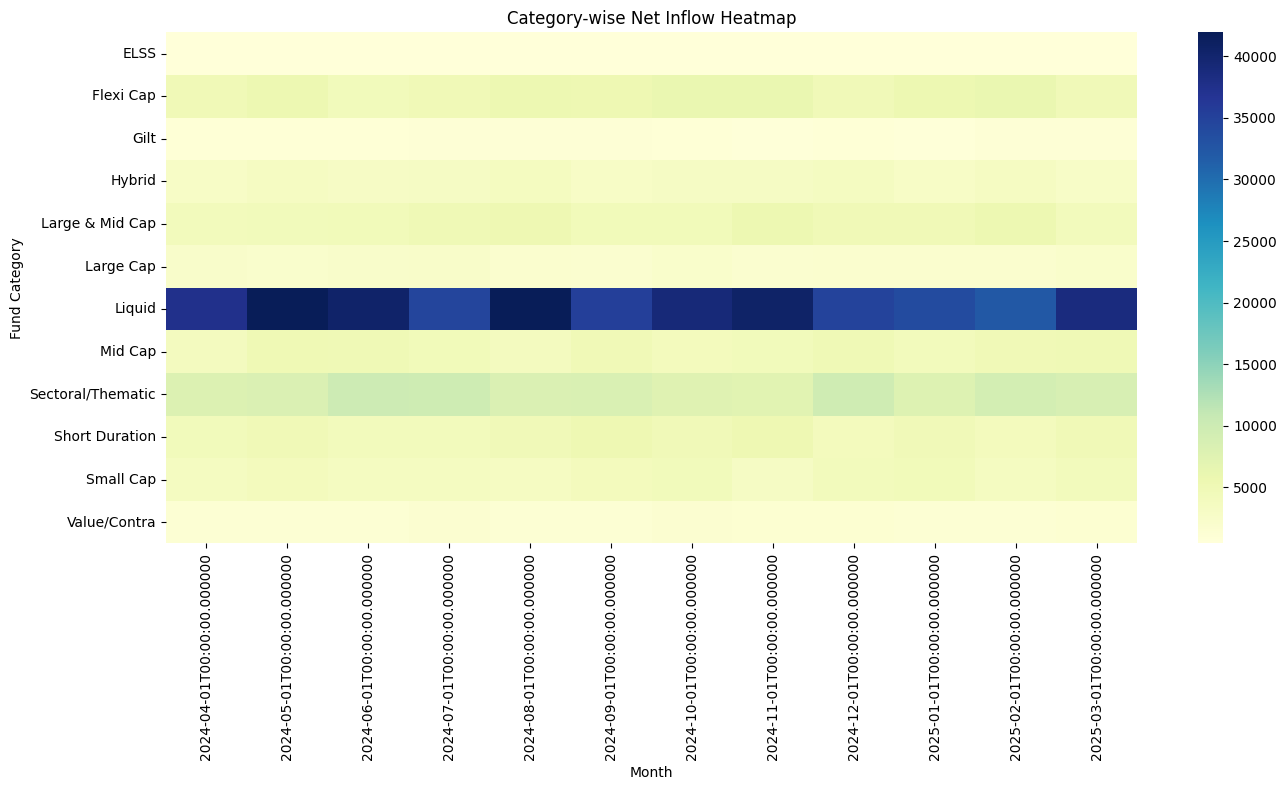

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert month column
category['month'] = pd.to_datetime(category['month'])

# Create pivot table
heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

# Plot heatmap
plt.figure(figsize=(14,8))
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()

plt.show()

### Category Inflow Analysis

Equity-oriented categories such as Flexi Cap, Mid Cap, and Small Cap consistently attracted higher inflows, indicating strong investor preference for growth-oriented investment strategies.

In [12]:
demo = pd.read_csv("../1.data/raw/08_investor_transactions.csv")

print(demo.head())
print(demo.columns)

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

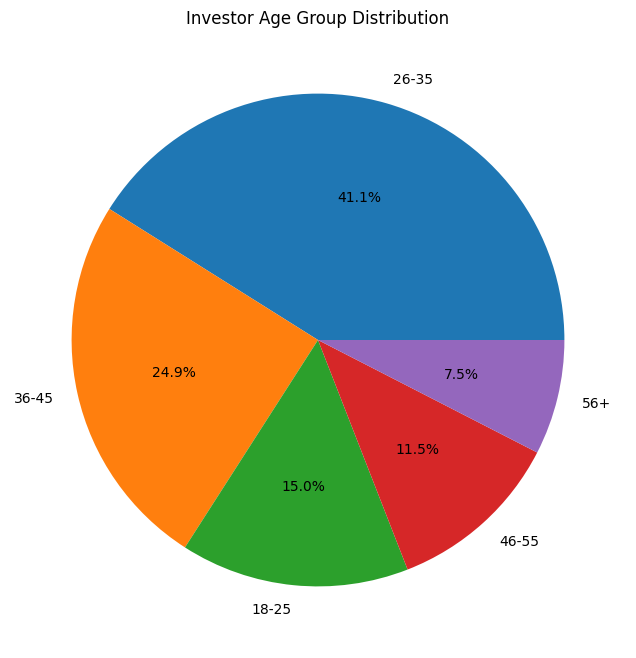

In [13]:
age_counts = demo['age_group'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")
plt.show()

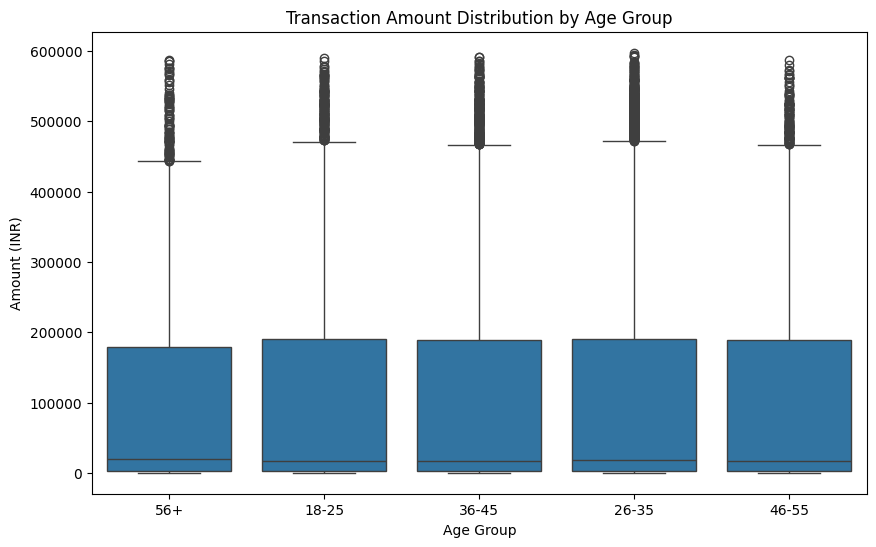

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=demo,
    x='age_group',
    y='amount_inr'
)

plt.title("Transaction Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")
plt.show()

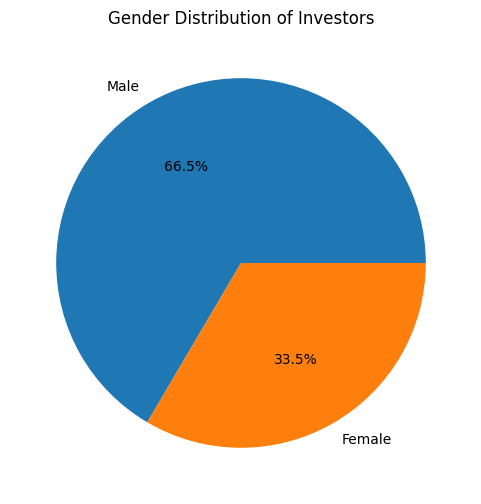

In [15]:
gender_counts = demo['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution of Investors")
plt.show()

### Investor Demographics Analysis

The majority of investors belong to the working-age population (26–45 years). Gender participation appears relatively balanced, with active investment behaviour observed across all age groups.

In [16]:
print(demo[['state', 'city_tier', 'amount_inr']].head())

         state city_tier  amount_inr
0    Telangana       T30        1834
1       Punjab       B30      392882
2      Haryana       B30         912
3  Maharashtra       T30        1102
4        Delhi       T30        8682


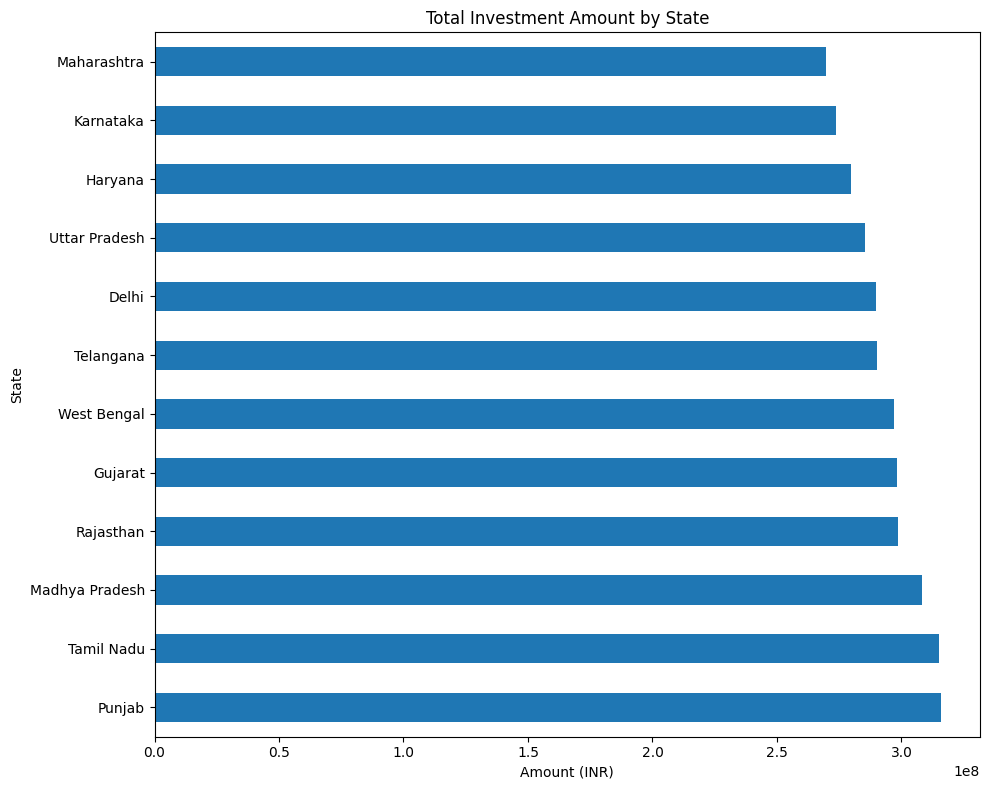

In [17]:
state_amount = demo.groupby('state')['amount_inr'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,8))

state_amount.plot(kind='barh')

plt.title("Total Investment Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

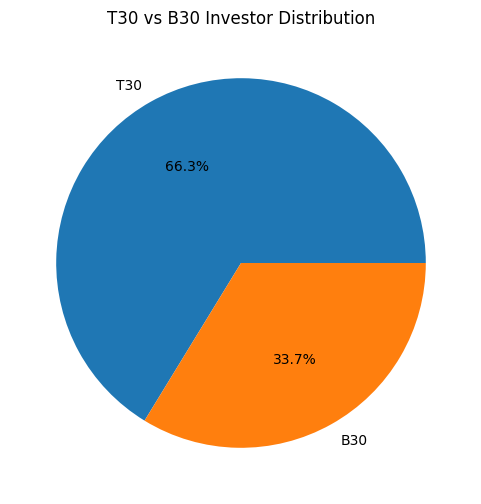

In [18]:
tier_counts = demo['city_tier'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

### Geographic Distribution Analysis

Metropolitan (T30) cities contribute a significant share of mutual fund investments, while B30 cities also show growing participation, indicating expanding financial inclusion across regions.


In [19]:
folio = pd.read_csv("../1.data/raw/06_industry_folio_count.csv")

print(folio.head())
print(folio.columns)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


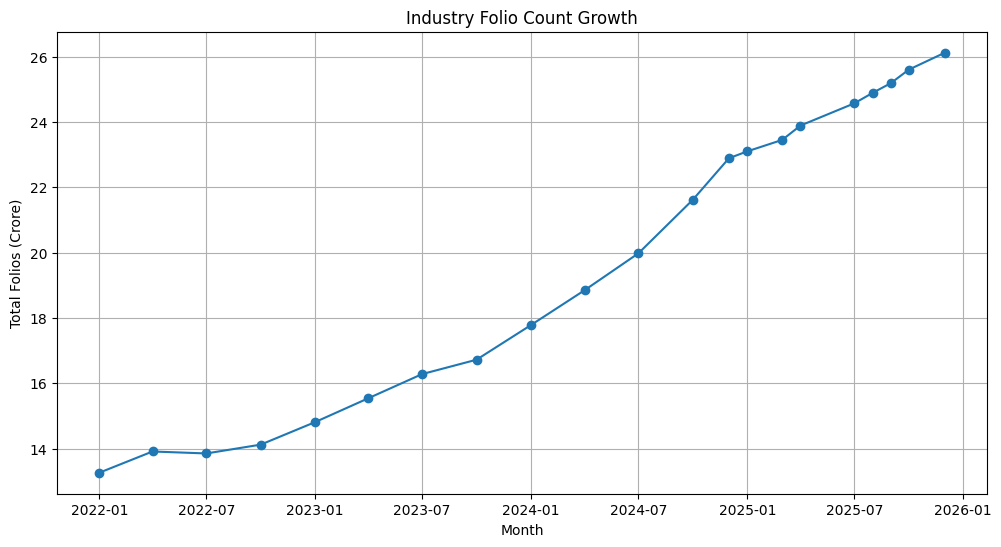

In [20]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title("Industry Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)
plt.show()

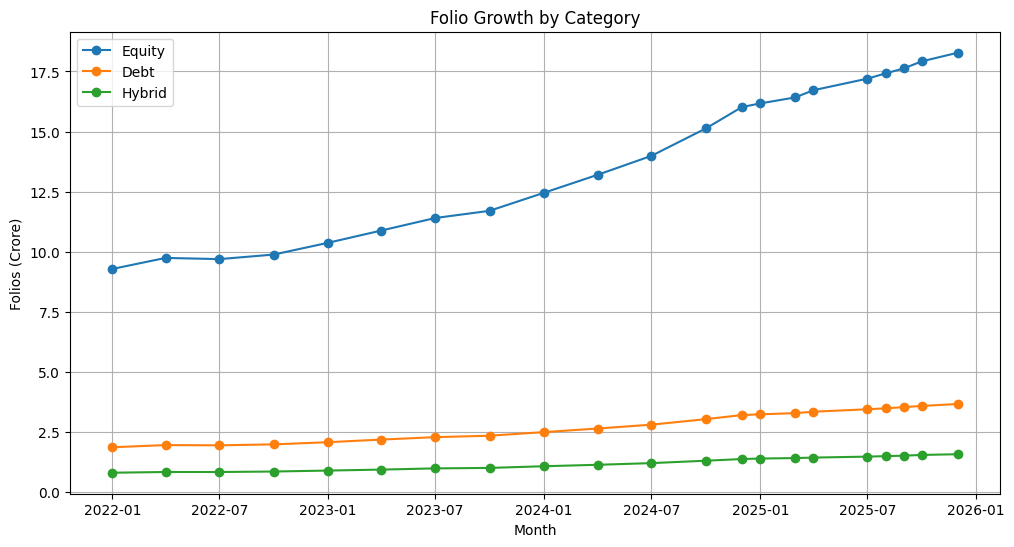

In [21]:
plt.figure(figsize=(12,6))

plt.plot(folio['month'], folio['equity_folios_crore'], marker='o', label='Equity')
plt.plot(folio['month'], folio['debt_folios_crore'], marker='o', label='Debt')
plt.plot(folio['month'], folio['hybrid_folios_crore'], marker='o', label='Hybrid')

plt.title("Folio Growth by Category")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.legend()

plt.grid(True)
plt.show()

### Folio Growth Analysis

Industry folio counts increased steadily over time, reflecting growing investor participation. Equity funds accounted for the majority of folio growth throughout the period.

In [22]:
print(nav['amfi_code'].nunique())
print(nav['amfi_code'].unique()[:10])

40
[100016 100025 100033 101206 101207 101208 102885 102886 102887 118632]


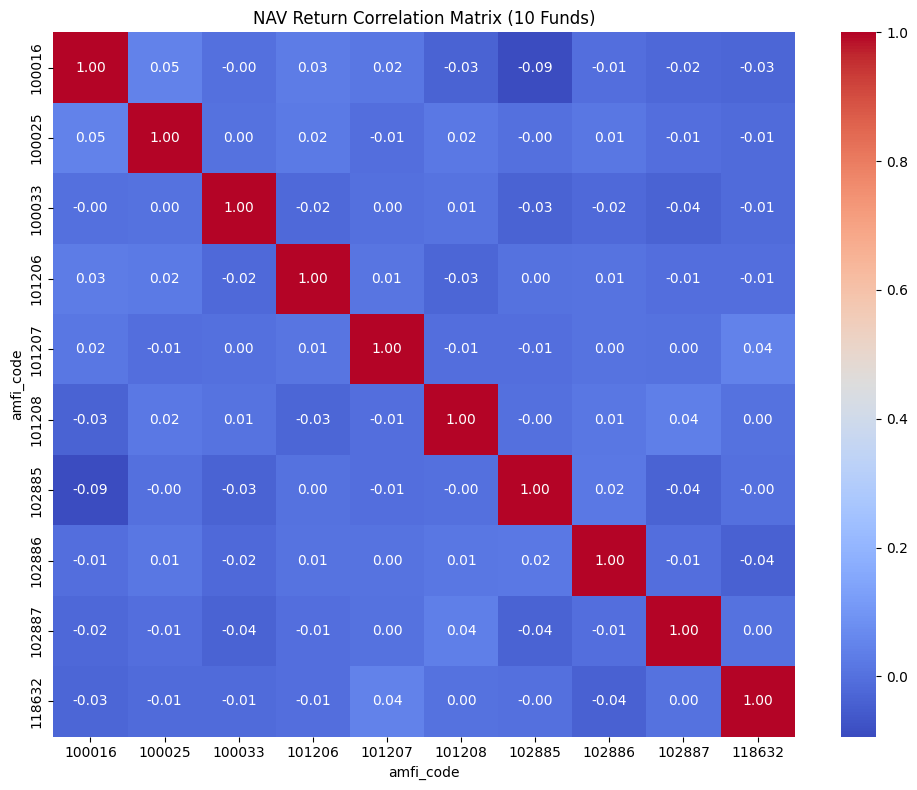

In [23]:
# Select first 10 funds
selected_funds = nav['amfi_code'].unique()[:10]

# Filter data
nav_subset = nav[nav['amfi_code'].isin(selected_funds)].copy()

# Pivot table
nav_pivot = nav_subset.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

# Calculate daily returns
returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("NAV Return Correlation Matrix (10 Funds)")
plt.tight_layout()
plt.show()

### NAV Correlation Analysis

Most mutual fund schemes exhibit positive return correlations, indicating that market-wide factors influence fund performance. However, the strength of correlation varies across schemes.

In [24]:
portfolio = pd.read_csv("../1.data/raw/09_portfolio_holdings.csv")

print(portfolio.head())
print(portfolio.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


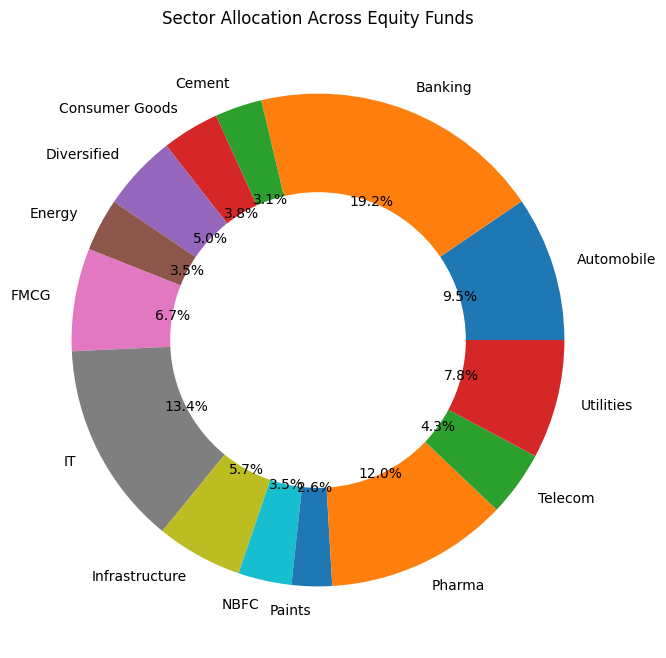

In [25]:
# Aggregate sector weights
sector_weights = portfolio.groupby('sector')['weight_pct'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

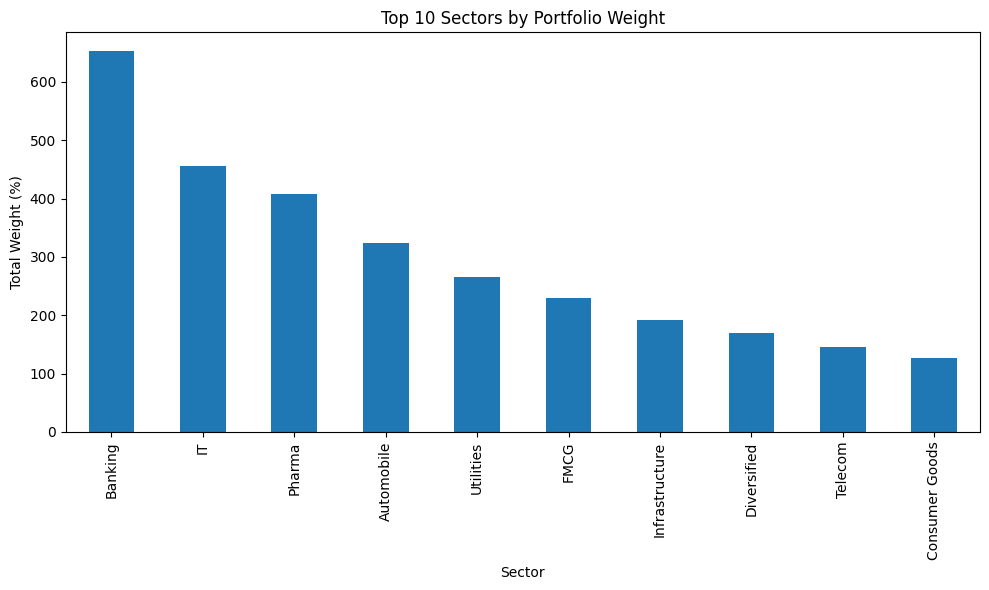

In [26]:
top_sectors = (
    portfolio.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_sectors.plot(kind='bar')

plt.title("Top 10 Sectors by Portfolio Weight")
plt.xlabel("Sector")
plt.ylabel("Total Weight (%)")

plt.tight_layout()
plt.show()

### Sector Allocation Analysis

Banking, financial services, and other core sectors occupy a significant share of mutual fund portfolios, reflecting their importance in diversified equity investment strategies.

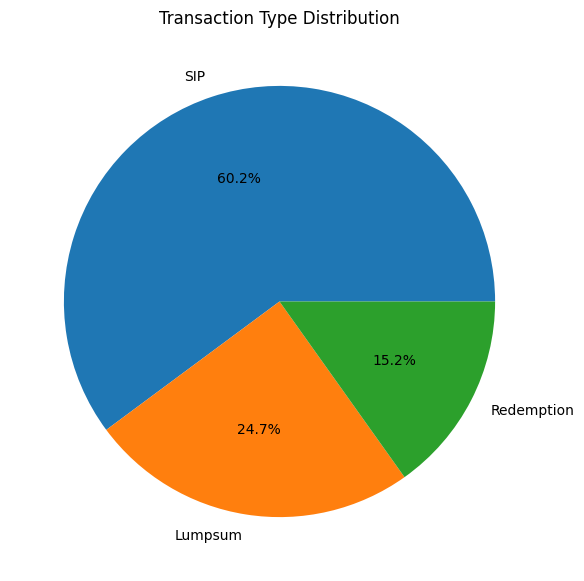

In [27]:
txn_counts = demo['transaction_type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    txn_counts,
    labels=txn_counts.index,
    autopct='%1.1f%%'
)

plt.title("Transaction Type Distribution")

plt.show()

### Transaction Pattern Analysis

SIP transactions form a substantial portion of investor activity, highlighting the growing popularity of disciplined and systematic investing among mutual fund investors.